# **Standard Performance Metrics**

**Pixel Error (L2 Norm):** The fundamental accuracy of the spatial grounding task is quantified using the **Euclidean displacement** between the model's **prediction (pred)** and the annotated **ground truth (gt)**. The absolute pixel error is described by:

$$E_{pixel} = \sqrt{(x_{pred} - x_{gt})^2 + (y_{pred} - y_{gt})^2}$$

where $(x_{pred}, y_{pred})$ are the coordinates of the predicted grasp point, and $(x_{gt}, y_{gt})$ are the coordinates of the ground-truth annotation.

**Normalized Pixel Error:** To ensure equitable comparison across varying image resolutions, the **pixel error is normalized** against the **physical dimensions (width $\times$ height) of the image**. The normalized pixel error is described by:

$$E_{norm} = \frac{E_{pixel}}{\sqrt{w^2 + h^2}}$$

where $w$ and $h$ are the width and height of the image, respectively, defining the diagonal length of the spatial domain.

**Success Rate:** The **functional success** of the model's localization is evaluated as a **binary thresholding problem**. The aggregate success rate is described by:

$$S_{rate} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}[E_{pixel, i} < \tau]$$

where $N$ is the total number of evaluated samples, $\tau$ is the acceptable pixel error threshold (e.g., `SUCCESS_THRESHOLD = 50`), and $\mathbf{1}[\cdot]$ is the indicator function which equals $1$ if the condition is met and $0$ otherwise.


# **Comparative Analysis**

**Prompt Sensitivity:** To evaluate the influence of linguistic variation, we measure the spatial displacement induced by alternating the **natural language prompt (e.g., grasp, point)**. Prompt sensitivity is described by:

$$\Delta_{\textit{prompt_shift}} = \sqrt{(x_{point} - x_{grasp})^2 + (y_{point} - y_{grasp})^2}$$

where $(x_{point}, y_{point})$ is the coordinate generated utilizing the "point to..." prefix phrasing, and $(x_{grasp}, y_{grasp})$ is the coordinate generated utilizing the "grasp..." prefix phrasing.

**Prompt Consistency:** The stability of the model against semantic perturbations is calculated as the **inverse of normalized sensitivity**. Prompt consistency is described by:

$$C_{prompt} = 1 - \frac{\Delta_{\textit{prompt_shift}}}{\sqrt{w^2 + h^2}}$$

where a value of $C_{prompt} \to 1$ indicates total resilience to prompt phrasing.

**Per-Category Error (Category Error):** To diagnose **model-specific failure modes** across different semantic objects, the aggregate category error is described by:

$$E_{category} = \frac{1}{N_{category}} \sum_{i \in \mathbb{C}} E_{pixel, i}$$

where $\mathbb{C}$ represents the subset of indices belonging to a specific object category, and $N_{category}$ is the total number of samples within that specific category's subset.

**Per-Prompt Error (Prompt Error):** The isolated performance of a **specific linguistic strategy** across the entire test set is evaluated. The prompt error is described by:

$$E_{prompt} = \frac{1}{N} \sum_{i=1}^{N} E_{pixel, i}^{prompt}$$

where $N$ is the total number of evaluated samples in the test set, and $E_{pixel, i}^{prompt}$ denotes the absolute pixel error for the $i$-th sample when evaluated under that specific semantic phrasing condition (e.g., using only the "point to..." prefix phrasing). This isolates the mean error strictly for one linguistic strategy prior to **hypothesis testing**.

In [1]:

# ============================================================================================
# Cell 1: Environment Initialization and Dependency Control
# ============================================================================================
!apt-get update -qq

# Florence-2:
# VLM architecture, vision processing, and data dependencies.
# Reminder: Specific versions are pinned to guarantee deterministic reproducibility for the comparative study.
!pip install -q transformers==4.49.0 accelerate==0.30.1 einops==0.8.0 datasets pillow matplotlib requests

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 97.7 MB/s eta 0:00:00


In [2]:

# ============================================================================================
# Cell 2: Global Library Imports and Namespace Initialization
# ============================================================================================
# 1. Standard Python Library Imports
import json
import math
import os
import random
from collections import defaultdict

# 2. Third-Party and External Library Imports
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from google.colab import drive
from PIL import Image
from scipy import stats
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoProcessor

In [3]:

# ============================================================================================
# Cell 3: Filesystem Integration and Hardware Resource Allocation
# ============================================================================================
drive.mount('/content/drive')

# NVIDIA GPU (CUDA) hardware acceleration for parallel VLM inference.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[STATUS] Hardware engine initialized: {device}")

DATASET_DIR = "/content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3"

# Defensive programming
assert os.path.exists(DATASET_DIR), f"[CRITICAL] Dataset directory not found at: {DATASET_DIR}"
print(f"[STATUS] Filesystem verified. Baseline directory located.")

Mounted at /content/drive
[STATUS] Hardware engine initialized: cuda
[STATUS] Filesystem verified. Baseline directory located.


In [4]:

# ============================================================================================
# Cell 4: Model Instantiation and Computational Precision Configuration
# ============================================================================================
model_id = "microsoft/Florence-2-large"
print(f"[STATUS] Initializing {model_id} with explicit FP16 precision...")

# Required to execute Florence-2's custom architecture scripts from Hugging Face.
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

# Force FP16 during instantiation to minimize memory footprint and prevent VRAM overflow.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    torch_dtype=torch.float16
).to(device).eval()

print(f"[STATUS] {model_id} successfully loaded and allocated on {device} (FP16).")

[STATUS] Initializing microsoft/Florence-2-large with explicit FP16 precision...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

[STATUS] microsoft/Florence-2-large successfully loaded and allocated on cuda (FP16).


In [5]:

# ============================================================================================
# Cell 5: Spatial Coordinate Logic and Deterministic Inference Orchestration
# ============================================================================================
# From RAW DATA ---> To STANDARDIZED PREDICTED COORDINATE
def get_box_center(box):
    """
    Translates Florence-2's bounding box output into the precise (x, y)
    coordinate required for robotic grasp-point evaluation.
    """
    x1, y1, x2, y2 = box
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    return (center_x, center_y)

def euclidean_distance(p1, p2):
    """
    Computes the pixel error metric for the comparative study.
    Quantifies absolute grasp-point displacement.
    """
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def inference(image, task_prompt, text_input=None):
    prompt = task_prompt if text_input is None else task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch.float16)

    # print(f"[DEBUG] Tensor shape fed to model: {inputs['pixel_values'].shape}")

    # Force deterministic generation (beam search, no sampling) to guarantee
    # experimental reproducibility across the evaluation set.
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        early_stopping=False,
        do_sample=False,
        num_beams=3,
    )

    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

    # Post-process textual output into absolute pixel coordinates
    # based on the original unscaled image dimensions.
    parsed_answer = processor.post_process_generation(
        generated_text,
        task=task_prompt,
        image_size=(image.width, image.height)
    )

    return parsed_answer

print("\n✅[STATUS] Inference utilities and coordinate logic initialized.")


✅[STATUS] Inference utilities and coordinate logic initialized.


In [6]:

# ============================================================================================
# Cell 6: Dataset Deserialization and Test Split Verification
# ============================================================================================
SPLIT_PATH = os.path.join(DATASET_DIR, "splits/test.json")
SPLIT_DIR = os.path.dirname(SPLIT_PATH)

# Fail fast: Ground-truth annotations are a hard dependency for the evaluation loop.
assert os.path.exists(SPLIT_PATH), f"[CRITICAL] Target split missing. Splits dir contents: {os.listdir(SPLIT_DIR)}"

with open(SPLIT_PATH, "r") as f:
    test_data = json.load(f)

print(f"[STATUS] Test split deserialized successfully. Total evaluation samples: {len(test_data)}")
print(f"[INFO] Data integrity check - sample target: '{test_data[0]['label']}'")

[STATUS] Test split deserialized successfully. Total evaluation samples: 183
[INFO] Data integrity check - sample target: 'apple'


In [7]:

# ============================================================================================
# Cell 7: Automated Dual-Prompt Inference and Metric Persistence
# ============================================================================================
# Local or cloud-based storage path for Florence-2 evaluation outputs.
OUTPUT_DIR = "/content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_preliminary_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[STATUS] Shared evaluation directory synchronized: {OUTPUT_DIR}")

# Define shared prompt logic to maintain linguistic parity with the CLIP baseline.
def make_prompt_point(label):
    hints = {
        "backpack":    "Point to the strap of the backpack.",
        "bag":         "Point to the handle of the bag.",
        "calculator":  "Point to the body of the calculator.",
        "charger":     "Point to the cable of the charger.",
        "hairbrush":   "Point to the handle of the hairbrush.",
        "headphones":  "Point to the band of the headphones.",
        "highlighter": "Point to the body of the highlighter.",
        "jar":         "Point to the lid of the jar.",
        "kettle":      "Point to the handle of the kettle.",
        "keyboard":    "Point to the center of the keyboard.",
        "laptop":      "Point to the edge of the laptop.",
        "mouse":       "Point to the body of the mouse.",
        "notebook":    "Point to the spine of the notebook.",
        "onion":       "Point to the center of the onion.",
        "remote":      "Point to the body of the remote.",
        "scissor":     "Point to the handle of the scissor.",
        "stapler":     "Point to the top of the stapler.",
        "tape":        "Point to the side of the tape.",
        "toothbrush":  "Point to the handle of the toothbrush.",
        "umbrella":    "Point to the handle of the umbrella.",
        "wallet":      "Point to the body of the wallet.",
        "watch":       "Point to the strap of the watch.",
        "apple":       "Point to the center of the apple.",
        "book":        "Point to the spine of the book.",
        "bottle":      "Point to the neck of the bottle.",
        "bowl":        "Point to the rim of the bowl.",
        "cup":         "Point to the handle of the cup.",
        "fork":        "Point to the handle of the fork.",
        "keys":        "Point to the ring of the keys.",
        "knife":       "Point to the handle of the knife.",
        "marker":      "Point to the body of the marker.",
        "mug":         "Point to the handle of the mug.",
        "pen":         "Point to the body of the pen.",
        "phone":       "Point to the body of the phone.",
        "plate":       "Point to the edge of the plate.",
        "shoe":        "Point to the heel of the shoe.",
        "spoon":       "Point to the handle of the spoon.",
        "tomato":      "Point to the center of the tomato.",
        "tray":        "Point to the edge of the tray.",
        "basket":      "Point to the handle of the basket.",
        "pot":         "Point to the handle of the pot.",
        "pan":         "Point to the handle of the pan.",
        "sock":        "Point to the opening of the sock.",
        "glove":       "Point to the cuff of the glove.",
        "t-shirt":     "Point to the collar of the t-shirt.",
        "earbuds":     "Point to the body of the earbuds.",
        "egg":         "Point to the center of the egg.",
        "spatula":     "Point to the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Point to the {label.lower()}.")

def make_prompt_grasp(label):
    hints = {
        "backpack":    "Grasp the strap of the backpack.",
        "bag":         "Grasp the handle of the bag.",
        "calculator":  "Grasp the body of the calculator.",
        "charger":     "Grasp the cable of the charger.",
        "hairbrush":   "Grasp the handle of the hairbrush.",
        "headphones":  "Grasp the band of the headphones.",
        "highlighter": "Grasp the body of the highlighter.",
        "jar":         "Grasp the lid of the jar.",
        "kettle":      "Grasp the handle of the kettle.",
        "keyboard":    "Grasp the center of the keyboard.",
        "laptop":      "Grasp the edge of the laptop.",
        "mouse":       "Grasp the body of the mouse.",
        "notebook":    "Grasp the spine of the notebook.",
        "onion":       "Grasp the center of the onion.",
        "remote":      "Grasp the body of the remote.",
        "scissor":     "Grasp the handle of the scissor.",
        "stapler":     "Grasp the top of the stapler.",
        "tape":        "Grasp the side of the tape.",
        "toothbrush":  "Grasp the handle of the toothbrush.",
        "umbrella":    "Grasp the handle of the umbrella.",
        "wallet":      "Grasp the body of the wallet.",
        "watch":       "Grasp the strap of the watch.",
        "apple":       "Grasp the center of the apple.",
        "book":        "Grasp the spine of the book.",
        "bottle":      "Grasp the neck of the bottle.",
        "bowl":        "Grasp the rim of the bowl.",
        "cup":         "Grasp the handle of the cup.",
        "fork":        "Grasp the handle of the fork.",
        "keys":        "Grasp the ring of the keys.",
        "knife":       "Grasp the handle of the knife.",
        "marker":      "Grasp the body of the marker.",
        "mug":         "Grasp the handle of the mug.",
        "pen":         "Grasp the body of the pen.",
        "phone":       "Grasp the body of the phone.",
        "plate":       "Grasp the edge of the plate.",
        "shoe":        "Grasp the heel of the shoe.",
        "spoon":       "Grasp the handle of the spoon.",
        "tomato":      "Grasp the center of the tomato.",
        "tray":        "Grasp the edge of the tray.",
        "basket":      "Grasp the handle of the basket.",
        "pot":         "Grasp the handle of the pot.",
        "pan":         "Grasp the handle of the pan.",
        "sock":        "Grasp the opening of the sock.",
        "glove":       "Grasp the cuff of the glove.",
        "t-shirt":     "Grasp the collar of the t-shirt.",
        "earbuds":     "Grasp the body of the earbuds.",
        "egg":         "Grasp the center of the egg.",
        "spatula":     "Grasp the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Grasp the {label.lower()}.")

PROMPTS = {"point": make_prompt_point, "grasp": make_prompt_grasp}
SUCCESS_THRESHOLD = 50
results = []
category_errors = defaultdict(list)
prompt_errors = defaultdict(list)

for entry in tqdm(test_data, desc="Evaluating Florence-2"):
    image_name = os.path.basename(entry["image_path"])
    image_full_path = os.path.join(DATASET_DIR, "images", image_name)
    target_label = entry["label"]

    try:
        img = Image.open(image_full_path).convert("RGB")
        w, h = img.size
        diagonal = math.sqrt(w**2 + h**2)

        # Dataset ground truths are stored as relative percentages. Convert to absolute
        # pixel coordinates to ensure spatial parity with Florence-2 outputs.
        gt_raw = entry["points"][0]
        gt_x_px = (gt_raw['x'] / 100.0) * w
        gt_y_px = (gt_raw['y'] / 100.0) * h

        p_data = {}
        for p_name, p_fn in PROMPTS.items():
            text_prompt = p_fn(target_label)
            raw_output = inference(img, "<CAPTION_TO_PHRASE_GROUNDING>", text_input=text_prompt)
            parsed = raw_output["<CAPTION_TO_PHRASE_GROUNDING>"]

            if len(parsed["bboxes"]) > 0:
                best_box = parsed["bboxes"][0]
                pred_x, pred_y = get_box_center(best_box)
                pixel_err = euclidean_distance((pred_x, pred_y), (gt_x_px, gt_y_px))

                p_data[p_name] = {
                    "text": text_prompt, "x": pred_x, "y": pred_y, "box": best_box,
                    "err": pixel_err, "norm_err": pixel_err / diagonal
                }

        # Compiling dual-prompt comparative metrics only for fully successful inferences.
        if "point" in p_data and "grasp" in p_data:
            p1, p2 = p_data["point"], p_data["grasp"]
            avg_err = (p1["err"] + p2["err"]) / 2.0

            # Quantify 'shift' variance for Hypothesis Testing (Prompt Sensitivity).
            shift = euclidean_distance((p1["x"], p1["y"]), (p2["x"], p2["y"]))
            consistency = round(1.0 - (shift / diagonal), 4)
            success = int(p1["err"] < SUCCESS_THRESHOLD and p2["err"] < SUCCESS_THRESHOLD)

            entry_dict = {
                "image_path": image_full_path,
                "label": target_label,
                "width": w,
                "height": h,
                "prompt_1": p1["text"],
                "pred_x_point": p1["x"],
                "pred_y_point": p1["y"],
                "pred_box_point": p1["box"],
                "pixel_error_point": p1["err"],
                "normalized_pixel_error_point": p1["norm_err"],
                "prompt_2": p2["text"],
                "pred_x_grasp": p2["x"],
                "pred_y_grasp": p2["y"],
                "pred_box_grasp": p2["box"],
                "pixel_error_grasp": p2["err"],
                "normalized_pixel_error_grasp": p2["norm_err"],
                "gt_x": gt_x_px,
                "gt_y": gt_y_px,
                "avg_pixel_error": round(avg_err, 2),
                "prompt_sensitivity": round(shift, 2),
                "prompt_consistency": consistency,
                "success_rate": success
            }
            results.append(entry_dict)
            category_errors[target_label].append(avg_err)
            prompt_errors["point"].append(p1["err"])
            prompt_errors["grasp"].append(p2["err"])

    except Exception as e:
        print(f"[RUNTIME ERROR] Instance {image_name} failed: {e}")
        continue

per_category_error = {cat: round(float(np.mean(errs)), 2) for cat, errs in category_errors.items()}
per_prompt_error = {p: round(float(np.mean(errs)), 2) for p, errs in prompt_errors.items()}

for r in results:
    r["per_category_error"] = per_category_error[r["label"]]
    r["per_prompt_error_point"] = per_prompt_error["point"]
    r["per_prompt_error_grasp"] = per_prompt_error["grasp"]

JSON_PATH = os.path.join(OUTPUT_DIR, "florence2_eval_results.json")
with open(JSON_PATH, "w") as f:
    json.dump(results, f, indent=2)

print(f"\n✅[STATUS] Inference complete. Standardized JSON Report generated at: {JSON_PATH}")

[STATUS] Shared evaluation directory synchronized: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_preliminary_results


Evaluating Florence-2: 100%|██████████| 183/183 [03:49<00:00,  1.26s/it]


✅[STATUS] Inference complete. Standardized JSON Report generated at: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_preliminary_results/florence2_eval_results.json


In [8]:

# ============================================================================================
# Cell 8: Quantitative Performance Evaluation and Hypothesis Testing
# ============================================================================================
errors_point = [r["pixel_error_point"] for r in results]
errors_grasp = [r["pixel_error_grasp"] for r in results]
sensitivity = [r["prompt_sensitivity"] for r in results]
success = [r["success_rate"] for r in results]

# Command Line Interface separator
TOTAL_WIDTH = 100
CLI_SEP = "=" * TOTAL_WIDTH

print(f"\n{' EVALUATION SUMMARY '.center(TOTAL_WIDTH, '=')}\n")
print(f"Total successful samples : {len(results)}")

print("\n--- Pixel Error (Point Prompt) ---")
print(f" Mean   : {np.mean(errors_point):.2f} px")
print(f" Median : {np.median(errors_point):.2f} px")

print("\n--- Pixel Error (Grasp Prompt) ---")
print(f" Mean   : {np.mean(errors_grasp):.2f} px")
print(f" Median : {np.median(errors_grasp):.2f} px")

print("\n--- Prompt Sensitivity (Coordinate Shift) ---")
print(f" Mean   : {np.mean(sensitivity):.2f} px")
print(f" Median : {np.median(sensitivity):.2f} px")

print("\n--- Success Rate (Combined Threshold < 50px) ---")
print(f" {np.mean(success)*100:.1f}% ({sum(success)}/{len(success)} samples)\n")

# A paired t-test is required to isolate the effect of the linguistic prompt
# by controlling for the inherent variance in image difficulty.
print(f"\n{' INFERENTIAL STATISTICS (HYPOTHESIS TESTING) '.center(TOTAL_WIDTH, '=')}\n")
print("H0: Semantic prompt variation has no significant effect on mean pixel error.")
print("H1: Prompt phrasing significantly alters the model's spatial grounding accuracy.")

t_stat, p_value = stats.ttest_rel(errors_point, errors_grasp)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

print("\nReminder[ENGR 510]: \nThe p-value is the probability of observing a difference in mean pixel error as extreme as our sample, assuming the null hypothesis is true.")

alpha = 0.05
if p_value < alpha:
    decision = "REJECT H0"
    conclusion = (
        f"Since the p-value {p_value:.4e} is less than the standard significance level (α={alpha}), "
        "we reject the null hypothesis, suggesting our data is statistically inconsistent with the assumption that prompt variation has no effect."
    )
    print(f"\n[DECISION] {decision} (p < {alpha})")
    print(f"CONCLUSION: {conclusion}")
else:
    decision = "FAIL TO REJECT H0"
    conclusion = (
        f"Since the p-value {p_value:.4e} is greater than the standard significance level (α={alpha}), "
        "we fail to reject the null hypothesis, suggesting our data is statistically consistent with the model being robust to semantic prompt shifts."
    )
    print(f"\n[DECISION] {decision} (p >= {alpha})")
    print(f"CONCLUSION: {conclusion}\n")
print(f"{CLI_SEP} \n")

hypothesis_data = {
    "evaluation_summary": {
        "total_successful_samples": len(results),
        "pixel_error_point": {
            "mean": round(float(np.mean(errors_point)), 2),
            "median": round(float(np.median(errors_point)), 2)
        },
        "pixel_error_grasp": {
            "mean": round(float(np.mean(errors_grasp)), 2),
            "median": round(float(np.median(errors_grasp)), 2)
        },
        "prompt_sensitivity_shift": {
            "mean": round(float(np.mean(sensitivity)), 2),
            "median": round(float(np.median(sensitivity)), 2)
        },
        "success_rate": {
            "percentage": round(float(np.mean(success) * 100), 1),
            "successful_samples": sum(success),
            "total_samples": len(success)
        }
    },
    "inferential_statistics": {
        "null_hypothesis": "Semantic prompt variation has no significant effect on mean pixel error.",
        "alternative_hypothesis": "Prompt phrasing significantly alters the model's spatial grounding accuracy.",
        "t_statistic": round(float(t_stat), 4),
        "p_value": float(p_value),
        "alpha_level": alpha,
        "decision": decision,
        "conclusion": conclusion
    }
}

HYPOTHESIS_JSON_PATH = os.path.join(OUTPUT_DIR, "hypothesis_testing.json")

with open(HYPOTHESIS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(hypothesis_data, f, indent=4, ensure_ascii=False)

print(f"✅[STATUS] Hypothesis testing metrics standardized and saved to: {HYPOTHESIS_JSON_PATH}")


======================================== EVALUATION SUMMARY ========================================

Total successful samples : 183

--- Pixel Error (Point Prompt) ---
 Mean   : 269.82 px
 Median : 127.26 px

--- Pixel Error (Grasp Prompt) ---
 Mean   : 261.71 px
 Median : 115.96 px

--- Prompt Sensitivity (Coordinate Shift) ---
 Mean   : 111.40 px
 Median : 0.97 px

--- Success Rate (Combined Threshold < 50px) ---
 22.4% (41/183 samples)


=========================== INFERENTIAL STATISTICS (HYPOTHESIS TESTING) ============================

H0: Semantic prompt variation has no significant effect on mean pixel error.
H1: Prompt phrasing significantly alters the model's spatial grounding accuracy.

T-Statistic: 0.4932
P-Value: 6.2244e-01

Reminder[ENGR 510]: 
The p-value is the probability of observing a difference in mean pixel error as extreme as our sample, assuming the null hypothesis is true.

[DECISION] FAIL TO REJECT H0 (p >= 0.05)
CONCLUSION: Since the p-value 6.2244e-01 is gre

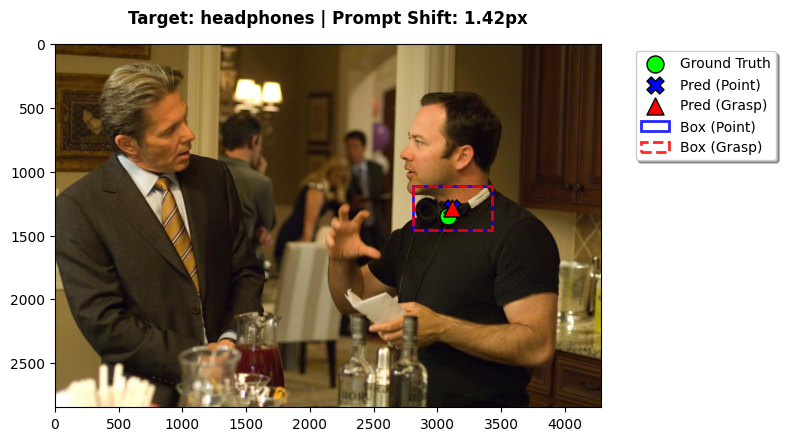

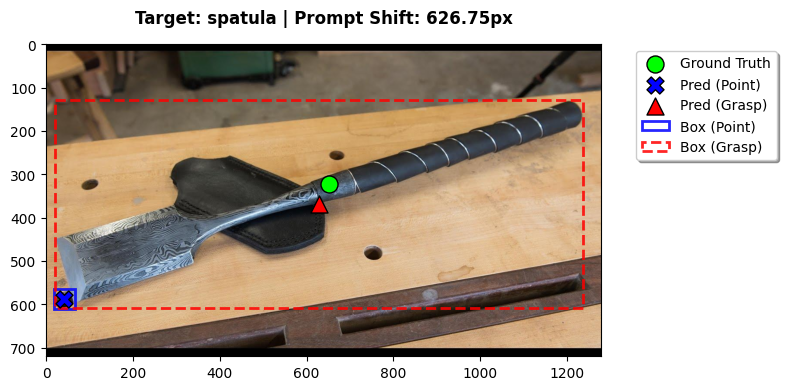

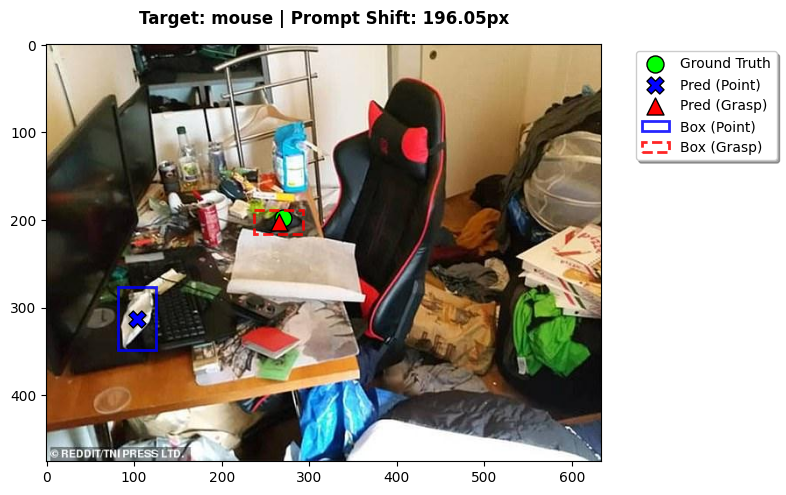

In [9]:

# ============================================================================================
# Cell 9: Qualitative Visual Verification and Spatial Mapping
# ============================================================================================
# Stochastic sampling to observe if coordinate 'shifts' align with semantic
# object affordances (e.g., handles vs. centroids).
sample_size = min(3, len(results))
samples = random.sample(results, sample_size)

for row in samples:
    img = Image.open(row['image_path']).convert("RGB")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)

    # 1. Plot the Centroid Dots
    # Ground Truth:
    ax.scatter(row['gt_x'], row['gt_y'], c='lime', s=150,
               label='Ground Truth', edgecolors='black', linewidths=1, zorder=4)
    # Point Pred:
    ax.scatter(row['pred_x_point'], row['pred_y_point'], c='blue', marker='X', s=150,
               edgecolors='black', linewidths=1, label='Pred (Point)', zorder=5)
    # Grasp Pred:
    ax.scatter(row['pred_x_grasp'], row['pred_y_grasp'], c='red', marker='^', s=150,
               edgecolors='black', linewidths=1, label='Pred (Grasp)', zorder=6)

    # 2. Draw the Bounding Boxes
    box_p = row['pred_box_point']

    rect_point = patches.Rectangle((box_p[0], box_p[1]), box_p[2] - box_p[0], box_p[3] - box_p[1],
                                   linewidth=2, edgecolor='blue', facecolor='none', linestyle='-', alpha=0.85, label='Box (Point)', zorder=3)
    ax.add_patch(rect_point)

    box_g = row['pred_box_grasp']

    rect_grasp = patches.Rectangle((box_g[0], box_g[1]), box_g[2] - box_g[0], box_g[3] - box_g[1],
                                   linewidth=2, edgecolor='red', facecolor='none', linestyle='--', alpha=0.85, label='Box (Grasp)', zorder=4)
    ax.add_patch(rect_grasp)

    ax.set_title(f"Target: {row['label']} | Prompt Shift: {row['prompt_sensitivity']}px", pad=15, fontweight='bold')

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', shadow=True)
    # plt.axis('off')
    plt.tight_layout()
    plt.show()

In [10]:

# ============================================================================================
# Cell 10: Edge-Case Identification and Model Failure Characterization
# ============================================================================================
if len(results) > 0:
    df_analysis = pd.DataFrame(results)

    # Instances where pixel error exceeds the functionally acceptable radius for robotic manipulation.
    threshold_failures = df_analysis[df_analysis['success_rate'] == 0]

    print(f"\n{' FAILURE CHARACTERIZATION REPORT '.center(TOTAL_WIDTH, '=')}\n")
    print(f"[REPORT] Aggregate Threshold Failures (>50px error): {len(threshold_failures)} / {len(df_analysis)} samples")

    if not threshold_failures.empty:
        # Failure distribution analysis identifies systemic class-level bottlenecks.
        # Top 5 Systemic Class Bottlenecks:
        print("\n[ANALYSIS] Distribution of class-specific localization failures:")
        bottlenecks = threshold_failures['label'].value_counts().head(5)
        for label, count in bottlenecks.items():
            print(f"  -> {label.capitalize()}: {count} failures")

        # Top 10 Diagnostic Edge-Cases
        print("\n[LOG] Diagnostic review candidates (Highest Error First):")
        worst_performers = threshold_failures.sort_values(by='avg_pixel_error', ascending=False)

        for _, row in worst_performers.head(10).iterrows():
            img_name = os.path.basename(row['image_path'])
            print(f" - {img_name:<16} (Target: {row['label']:<10}): Avg Error {row['avg_pixel_error']:>7.2f}px | Prompt Shift: {row['prompt_sensitivity']:>6.2f}px")

    print(f"\n{CLI_SEP}\n")
else:
    print("[CRITICAL WARNING] No successful results to analyze.")


================================= FAILURE CHARACTERIZATION REPORT ==================================

[REPORT] Aggregate Threshold Failures (>50px error): 142 / 183 samples

[ANALYSIS] Distribution of class-specific localization failures:
  -> Apple: 4 failures
  -> Backpack: 4 failures
  -> Bag: 4 failures
  -> Calculator: 4 failures
  -> Fork: 4 failures

[LOG] Diagnostic review candidates (Highest Error First):
 - bag_9.jpg        (Target: bag       ): Avg Error 3068.71px | Prompt Shift: 1768.90px
 - cup_6.jpg        (Target: cup       ): Avg Error 2926.86px | Prompt Shift:   3.37px
 - pan_18.jpg       (Target: pan       ): Avg Error 1990.77px | Prompt Shift:   0.00px
 - pot_3.jpg        (Target: pot       ): Avg Error 1268.24px | Prompt Shift:   2.02px
 - tray_10.jpg      (Target: tray      ): Avg Error 1093.46px | Prompt Shift:   2.48px
 - toothbrush_9.jpg (Target: toothbrush): Avg Error 1049.91px | Prompt Shift: 1585.34px
 - charger_18.jpg   (Target: charger   ): Avg Error  993.

In [11]:

# ============================================================================================
# Cell 11: Automated Technical Reporting Dependencies and Module Initialization
# ============================================================================================
!pip install -q reportlab

import os
import pandas as pd

# ReportLab Specific Imports
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph, SimpleDocTemplate, Spacer, Table, TableStyle, PageBreak

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.3 MB/s eta 0:00:00


In [12]:

# ============================================================================================
# Cell 12: Document Synthesis (PDF)
# ============================================================================================
PDF_PATH = os.path.join(OUTPUT_DIR, "Florence2_Dual_Prompt_Report.pdf")

def generate_pdf(output_path, results_list):
    if not results_list:
        print("[WARNING] No data to generate PDF.")
        return

    df = pd.DataFrame(results_list)

    class CanvasPDF(canvas.Canvas):
        def __init__(self, *args, **kwargs):
            canvas.Canvas.__init__(self, *args, **kwargs)
            self._saved_page_states = []

        def showPage(self):
            self._saved_page_states.append(dict(self.__dict__))
            self._startPage()

        def save(self):
            num_pages = len(self._saved_page_states)
            for state in self._saved_page_states:
                self.__dict__.update(state)
                self.draw_page_number(num_pages)
                canvas.Canvas.showPage(self)
            canvas.Canvas.save(self)

        def draw_page_number(self, page_count):
            self.saveState()

            page_text = f"Page {self._pageNumber} of {page_count}"
            self.setFont("Helvetica", 9)
            self.setFillColor(colors.gray)
            self.drawRightString(letter[0] - 40, 30, page_text)

            self.restoreState()

    SUCCESS_THRESHOLD = 50
    df['success_point'] = (df['pixel_error_point'] <= SUCCESS_THRESHOLD).astype(int)
    df['success_grasp'] = (df['pixel_error_grasp'] <= SUCCESS_THRESHOLD).astype(int)

    df['dual_success'] = ((df['success_point'] == 1) & (df['success_grasp'] == 1)).astype(int)

    df['norm_err_point'] = df['normalized_pixel_error_point'] * 100
    df['norm_err_grasp'] = df['normalized_pixel_error_grasp'] * 100

    agg_df = df.groupby('label').agg(
        count=('label', 'count'),
        avg_point_err=('pixel_error_point', 'mean'),
        avg_grasp_err=('pixel_error_grasp', 'mean'),
        avg_norm_err_point=('norm_err_point', 'mean'),
        avg_norm_err_grasp=('norm_err_grasp', 'mean'),
        avg_shift=('prompt_sensitivity', 'mean'),
        success_point_rate=('success_point', lambda x: x.mean() * 100),
        success_grasp_rate=('success_grasp', lambda x: x.mean() * 100)
    ).reset_index().sort_values(by='avg_shift', ascending=False)

    # --- DOCUMENT SETUP ---
    doc = SimpleDocTemplate(output_path, pagesize=letter, rightMargin=40, leftMargin=40, topMargin=50, bottomMargin=60)
    styles = getSampleStyleSheet()

    title_style = ParagraphStyle('TitleStyle', parent=styles['Heading1'], fontName='Helvetica-Bold', fontSize=16, alignment=1, spaceAfter=15)
    h2_style = ParagraphStyle('H2Style', parent=styles['Heading2'], fontName='Helvetica-Bold', fontSize=12, spaceBefore=15, spaceAfter=5)
    normal_style = ParagraphStyle('NormalStyle', parent=styles['Normal'], fontName='Helvetica', fontSize=10, leading=16)
    legend_style = ParagraphStyle('LegendStyle', parent=styles['Normal'], fontName='Helvetica-Oblique', fontSize=9, textColor=colors.dimgrey, spaceAfter=10)

    oxford_blue = colors.HexColor('#1f497d')
    elements = []

    elements.append(Paragraph("Zero-Shot VLM Evaluation: Florence-2 Report", title_style))
    elements.append(Paragraph("<b>Research Lead:</b> Jannine G. D. MacGormain", normal_style))
    elements.append(Spacer(1, 15))

    elements.append(Paragraph("1. Standard Performance Metrics", h2_style))

    global_metrics = (
        f"<b>Total Evaluated Samples:</b> {len(df)} images<br/>"
        f"<b>Success Rate ('Point' Prompt):</b> {df['success_point'].mean() * 100:.1f}%<br/>"
        f"<b>Success Rate ('Grasp' Prompt):</b> {df['success_grasp'].mean() * 100:.1f}%<br/>"
        f"<b>Per-Prompt Error ('Point' Prompt):</b> {df['pixel_error_point'].mean():.2f} pixels<br/>"
        f"<b>Per-Prompt Error ('Grasp' Prompt):</b> {df['pixel_error_grasp'].mean():.2f} pixels<br/>"
        f"<b>Prompt Sensitivity:</b> {df['prompt_sensitivity'].mean():.2f} pixels<br/>"
        f"<b>Prompt Consistency:</b> {df['prompt_consistency'].mean():.4f}<br/>"
        f"<b>Dual-Prompt Success Rate (Both &lt;50px):</b> {df['dual_success'].mean() * 100:.2f}%"
    )
    elements.append(Paragraph(global_metrics, normal_style))
    elements.append(Spacer(1, 15))

    elements.append(Paragraph("2. Comparative Analysis: Per-Category Metrics", h2_style))

    table_1_legend = "<b>Legend:</b> <b>Pt</b> = 'Point to...' Prompt | <b>Gr</b> = 'Grasp...' Prompt | <b>Px Err</b> = Pixel Error | <b>Norm Err</b> = Normalized Error | <b>Shift</b> = Prompt Sensitivity | <b>Succ</b> = Success Rate (&lt;50px)"
    elements.append(Paragraph(table_1_legend, legend_style))

    agg_header = [["Category", "Samples", "Px Err (Pt)", "Px Err (Gr)", "Norm Err (Pt)", "Norm Err (Gr)", "Shift (px)", "Succ (Pt)", "Succ (Gr)"]]
    agg_body = []

    for idx, (_, row) in enumerate(agg_df.iterrows(), start=1):
        agg_body.append([
            row['label'].capitalize(), str(row['count']),
            f"{row['avg_point_err']:.1f}", f"{row['avg_grasp_err']:.1f}",
            f"{row['avg_norm_err_point']:.1f}%", f"{row['avg_norm_err_grasp']:.1f}%",
            f"{row['avg_shift']:.1f}", f"{row['success_point_rate']:.0f}%", f"{row['success_grasp_rate']:.0f}%"
        ])

    # agg_body.append(["TOTAL", str(len(df)), "", "", "", "", "", "", ""])

    agg_body.append([
        "AGGREGATE",
        str(len(df)),
        f"{df['pixel_error_point'].mean():.1f}",
        f"{df['pixel_error_grasp'].mean():.1f}",
        f"{df['norm_err_point'].mean():.1f}%",
        f"{df['norm_err_grasp'].mean():.1f}%",
        f"{df['prompt_sensitivity'].mean():.1f}",
        f"{df['success_point'].mean()*100:.1f}%",
        f"{df['success_grasp'].mean()*100:.1f}%"
        ])

    agg_table = Table(agg_header + agg_body, hAlign='CENTER', colWidths=[80, 45, 55, 55, 60, 60, 50, 55, 55], repeatRows=1)

    agg_table_style = [
        ('BACKGROUND', (0, 0), (-1, 0), oxford_blue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('GRID', (0, 0), (-1, -2), 0.5, colors.grey),
        ('ALIGN', (0, 0), (-1, 0), 'CENTER'),
        ('ALIGN', (0, 1), (-1, -1), 'CENTER'),
        ('ALIGN', (0, 1), (0, -1), 'LEFT'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTNAME', (0, 1), (-1, -2), 'Helvetica'),
        ('FONTSIZE', (0, 0), (-1, -1), 8),

        ('FONTNAME', (0, -1), (-1, -1), 'Helvetica-Bold'),
        ('BACKGROUND', (0, -1), (-1, -1), colors.HexColor('#e6eef5')),
        ('BOX', (0, -1), (-1, -1), 2, oxford_blue),
        ('INNERGRID', (0, -1), (-1, -1), 0.5, colors.grey)
    ]

    for i in range(1, len(agg_df) + 1):
        bg_color = colors.whitesmoke if i % 2 != 0 else colors.lightgrey
        agg_table_style.append(('BACKGROUND', (0, i), (-1, i), bg_color))

    agg_table.setStyle(TableStyle(agg_table_style))
    elements.append(agg_table)

    elements.append(PageBreak())
    elements.append(Paragraph("3. Qualitative Analysis: Raw Data Pipeline", h2_style))

    table_2_legend = "<b>Legend:</b> <b>Size</b> = Image Dimensions (w,h) | <b>GT</b> = Ground Truth Coordinates | <b>Pt</b> = 'Point to...' Prediction | <b>Gr</b> = 'Grasp...' Prediction | <b>Px Err</b> = Pixel Error | <b>Shift</b> = Prompt Sensitivity"
    elements.append(Paragraph(table_2_legend, legend_style))

    raw_header = [["Image", "Size (w,h)", "GT (x,y)", "Pt (x,y)", "Gr (x,y)", "Px Err (Pt)", "Px Err (Gr)", "Shift"]]
    raw_body = []

    worst_performers = df.sort_values(by='prompt_sensitivity', ascending=False).head(40)

    for idx, (_, row) in enumerate(worst_performers.iterrows(), start=1):
        img_name = os.path.basename(row['image_path'])

        img_size = f"{int(row.get('width', 0))}x{int(row.get('height', 0))}"

        gt_coord = f"({int(row['gt_x'])}, {int(row['gt_y'])})"
        pt_coord = f"({int(row['pred_x_point'])}, {int(row['pred_y_point'])})"
        gr_coord = f"({int(row['pred_x_grasp'])}, {int(row['pred_y_grasp'])})"

        raw_body.append([
            img_name, img_size, gt_coord, pt_coord, gr_coord,
            f"{row['pixel_error_point']:.1f}", f"{row['pixel_error_grasp']:.1f}", f"{row['prompt_sensitivity']:.1f}"
        ])

    raw_table = Table(raw_header + raw_body, hAlign='CENTER', colWidths=[95, 60, 65, 65, 65, 50, 50, 45], repeatRows=1)

    raw_table_style = [
        ('BACKGROUND', (0, 0), (-1, 0), oxford_blue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
        ('ALIGN', (0, 0), (-1, 0), 'CENTER'),
        ('ALIGN', (0, 1), (-1, -1), 'CENTER'),
        ('ALIGN', (0, 1), (0, -1), 'LEFT'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTNAME', (0, 1), (-1, -1), 'Helvetica'),
        ('FONTSIZE', (0, 0), (-1, -1), 8),
        ('BOTTOMPADDING', (0, 0), (-1, -1), 5),
        ('TOPPADDING', (0, 0), (-1, -1), 5)
    ]

    for i in range(1, len(worst_performers) + 1):
        bg_color = colors.whitesmoke if i % 2 != 0 else colors.lightgrey
        raw_table_style.append(('BACKGROUND', (0, i), (-1, i), bg_color))

    raw_table.setStyle(TableStyle(raw_table_style))
    elements.append(raw_table)

    doc.build(elements, canvasmaker=CanvasPDF)

generate_pdf(PDF_PATH, results)
print(f"✅ [STATUS] Technical PDF report synthesized successfully: {PDF_PATH}")

✅ [STATUS] Technical PDF report synthesized successfully: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_preliminary_results/Florence2_Dual_Prompt_Report.pdf


In [13]:

# ============================================================================================
# Cell 13: Aggregate JSON Outputs (Florence-2 Baseline)
# ============================================================================================
# Synchronizing Florence-2 results with CLIP/DINO comparative study architecture.

df_final = pd.DataFrame(results)

# test_final_per_image.json: Raw metric log for spatial parity verification.
with open(os.path.join(OUTPUT_DIR, "test_final_per_image.json"), "w") as f:
    json.dump(results, f, indent=4)

# test_final_per_category.json: Aggregated class-level error distribution.
with open(os.path.join(OUTPUT_DIR, "test_final_per_category.json"), "w") as f:
    json.dump(per_category_error, f, indent=4)

# test_final_summary.json: Standard performance metrics (Grounding Success & Error).
summary_payload = {
    "model_id": "Florence-2-large",
    "total_samples": len(results),
    "standard_metrics": {
        "mean_pixel_error_point": round(float(df_final['pixel_error_point'].mean()), 2),
        "mean_pixel_error_grasp": round(float(df_final['pixel_error_grasp'].mean()), 2),
        "mean_prompt_sensitivity": round(float(df_final['prompt_sensitivity'].mean()), 2),
        "overall_success_rate": round(float(df_final['success_rate'].mean()), 4)
    }
}
with open(os.path.join(OUTPUT_DIR, "test_final_summary.json"), "w") as f:
    json.dump(summary_payload, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "val_prompt_eval.json"), "w") as f:
    json.dump(results, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "val_prompt_summary.json"), "w") as f:
    json.dump(summary_payload["standard_metrics"], f, indent=4)

print(f"✅ [STATUS] Aggregate JSON Outputs successfully generated in: {OUTPUT_DIR}")

✅ [STATUS] Aggregate JSON Outputs successfully generated in: /content/drive/MyDrive/Grasp Point Prediction/outputs/florence2_preliminary_results
